# Big Dataset Comparison: ML vs DL on Tabular Data

**Dataset:** Covertype - 581,012 rows x 54 features, 7 classes.

**What this notebook does:**
1. Loads the Covertype dataset and creates one fixed train / validation / test split with stratification.
2. Fits one shared `StandardScaler` on the training fold and reuses it everywhere, so every model sees identical inputs.
3. Trains four models on the same scaled data:
   - **Logistic Regression** - linear, explainable ML baseline.
   - **XGBoost** - gradient-boosted decision trees, the strong tabular ML model the project requirement calls out.
   - **MLP (sklearn)** - a small feed-forward neural net, the simplest DL baseline.
   - **TabNet** - attention-based DL architecture designed for tabular data, the proper DL counterpart to XGBoost.
4. Reports accuracy, macro precision / recall / F1, ROC-AUC, training time, and inference time, plus confusion matrices and ROC curves.
5. Saves the final comparison table, validation search results, coefficients, plots, models, and scaler into the `artifacts/big_dataset/` folder.

**Why this comparison is fair:** every model is trained on the same scaled training matrix and evaluated on the same scaled validation and test matrices. No model-specific feature engineering, no augmentation, no leakage.

**Presentation note:** each section includes what the next code cell does and what output to explain in class.

## 0a) Environment setup (dependencies)

This code cell checks whether `xgboost` and `pytorch-tabnet` are available, and installs them only if they are missing.

In [1]:
try:
    import xgboost  # noqa: F401
except ImportError:
    %pip install -q xgboost
try:
    import pytorch_tabnet  # noqa: F401
except ImportError:
    %pip install -q pytorch-tabnet

### Output and result

If dependencies are already present, this cell usually prints nothing. If a package is missing, you'll see the corresponding installation logs, after which later model-import cells run normally.

## 0b) Imports, paths, and reproducibility

This code cell imports libraries, sets seeds, resolves the dataset path, creates artifact folders, and defines global runtime settings used by all later cells.

In [2]:
import warnings
import json
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score, confusion_matrix, f1_score,
    precision_score, recall_score, roc_auc_score, roc_curve,
)
from sklearn.model_selection import ParameterGrid, train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

PROJECT_ROOT = Path.cwd()
DATA_CANDIDATES = [
    PROJECT_ROOT / "dataset" / "datasetBig" / "covtype.csv",
    PROJECT_ROOT / "Data Set big" / "covtype.csv",
    PROJECT_ROOT / "Data set big" / "covtype.csv",
    PROJECT_ROOT / "datasetBig" / "covtype.csv",
]


def resolve_existing_path(candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find covtype.csv. Checked: " + ", ".join(str(p) for p in candidates)
    )


DATA_PATH = resolve_existing_path(DATA_CANDIDATES)
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "big_dataset"
FIGURES_DIR = ARTIFACTS_DIR / "figures"
MODELS_DIR = ARTIFACTS_DIR / "models"
METRICS_DIR = ARTIFACTS_DIR / "metrics"

for folder in [ARTIFACTS_DIR, FIGURES_DIR, MODELS_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# README guidance allows fixed stratified subsets for heavy training. The same
# subset is consumed by EVERY model below, so the comparison stays fair.
USE_TRAIN_SUBSET_FOR_MODELING = True
MAX_TRAIN_SAMPLES = 120000
N_INFERENCE_REPEATS = 20

print(f"Project root: {PROJECT_ROOT}")
print(f"Using dataset: {DATA_PATH}")
print(f"Artifacts folder: {ARTIFACTS_DIR}")
print(f"Torch device available: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Project root: /teamspace/studios/this_studio
Using dataset: /teamspace/studios/this_studio/dataset/datasetBig/covtype.csv
Artifacts folder: /teamspace/studios/this_studio/artifacts/big_dataset
Torch device available: cpu


### Output and result

The printed lines confirm project root, selected dataset path, artifact directory, and available device (`cpu` in this run). This verifies the environment is ready for training and evaluation.

## 1) Load the dataset

This code cell reads `covtype.csv`, removes accidental unnamed columns if present, separates `X` and `y`, and displays a quick data preview with shape details.

In [3]:
df = pd.read_csv(DATA_PATH)

empty_cols = [c for c in df.columns if str(c).lower().startswith("unnamed")]
if empty_cols:
    df = df.drop(columns=empty_cols)

TARGET_COL = "Cover_Type" if "Cover_Type" in df.columns else df.columns[-1]
X_raw = df.drop(columns=[TARGET_COL]).copy()
y_raw = df[TARGET_COL].copy()
feature_cols = X_raw.columns.tolist()

display(df.head())
print(f"Shape: {df.shape}")
print(f"Target column: {TARGET_COL}")
print(f"Feature count: {len(feature_cols)}")

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


Shape: (581012, 55)
Target column: Cover_Type
Feature count: 54


### Output and result

The preview shows valid feature/target columns and sample rows. The printed summary confirms the full dataset size: **581,012 rows, 55 columns total, 54 features + 1 target (`Cover_Type`)**.

## 2) Validate and re-index the target

This code cell checks missing values and duplicates, enforces numeric typing, and remaps original class labels `1..7` into internal labels `0..6` for consistent multiclass modeling.

In [4]:
missing_values = df.isna().sum().sum()
duplicate_rows = df.duplicated().sum()

print(f"Total missing values: {missing_values}")
print(f"Duplicate rows: {duplicate_rows}")

X = X_raw.apply(pd.to_numeric, errors="raise")
y_numeric = pd.to_numeric(y_raw, errors="raise").astype(int)

raw_classes = np.sort(y_numeric.unique())
class_to_index = {cls: idx for idx, cls in enumerate(raw_classes)}
index_to_class = {idx: int(cls) for cls, idx in class_to_index.items()}
y = y_numeric.map(class_to_index).astype(int)
N_CLASSES = len(raw_classes)

print(f"Class count: {N_CLASSES}")
print("Class mapping (internal -> original):", index_to_class)
print("Class balance (normalized):")
print(y.value_counts(normalize=True).sort_index())

Total missing values: 0
Duplicate rows: 0
Class count: 7
Class mapping (internal -> original): {0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7}
Class balance (normalized):
Cover_Type
0    0.364605
1    0.487599
2    0.061537
3    0.004728
4    0.016339
5    0.029891
6    0.035300
Name: proportion, dtype: float64


### Output and result

Data quality checks are clean (**0 missing values, 0 duplicate rows**). The mapping confirms 7 classes, and class proportions show imbalance, which is why macro metrics are emphasized later.

## 3) Stratified split + tractable training subset

This code cell creates a stratified 70/15/15 train-validation-test split, then applies a fixed stratified training cap (`MAX_TRAIN_SAMPLES = 120000`) for fair and tractable model training.

In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_STATE,
)

val_ratio_within_train_val = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=val_ratio_within_train_val,
    stratify=y_train_val, random_state=RANDOM_STATE,
)

X_train_model = X_train.copy()
y_train_model = y_train.copy()

if USE_TRAIN_SUBSET_FOR_MODELING and len(X_train_model) > MAX_TRAIN_SAMPLES:
    X_train_model, _, y_train_model, _ = train_test_split(
        X_train_model, y_train_model,
        train_size=MAX_TRAIN_SAMPLES,
        stratify=y_train_model, random_state=RANDOM_STATE,
    )

print("Split sizes (full):")
print(f"Train full: {len(X_train)}")
print(f"Validation: {len(X_val)}")
print(f"Test: {len(X_test)}")
print("\nRows used for model fitting:", len(X_train_model))

Split sizes (full):
Train full: 406708
Validation: 87152
Test: 87152

Rows used for model fitting: 120000


### Output and result

The split is successful and balanced: **Train full 406,708 / Validation 87,152 / Test 87,152**. The shared modeling subset is **120,000** rows, which keeps runtime manageable while preserving fairness across models.

## 4) Shared preprocessing + metric helpers

This code cell fits one shared `StandardScaler`, transforms train/validation/test features, and defines reusable helper functions for prediction scores, common metrics, and macro ROC curves.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_model)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

y_train_arr = y_train_model.to_numpy()
y_val_arr = y_val.to_numpy()
y_test_arr = y_test.to_numpy()


def get_class_scores(model, X_input):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_input)
    raise ValueError(f"Model {type(model).__name__} does not expose predict_proba.")


def compute_common_metrics(y_true, y_pred, y_score):
    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
    }
    if y_score.ndim == 2 and y_score.shape[1] > 2:
        metrics["roc_auc"] = float(
            roc_auc_score(y_true, y_score, multi_class="ovr", average="macro")
        )
    else:
        positive_score = y_score[:, 1] if y_score.ndim == 2 else y_score
        metrics["roc_auc"] = float(roc_auc_score(y_true, positive_score))
    return metrics


def compute_macro_roc_curve(y_true, y_score, n_classes):
    if n_classes <= 2:
        positive_score = y_score[:, 1] if y_score.ndim == 2 else y_score
        fpr, tpr, _ = roc_curve(y_true, positive_score)
        return fpr, tpr
    y_bin = label_binarize(y_true, classes=np.arange(n_classes))
    grid = np.linspace(0, 1, 400)
    mean_tpr = np.zeros_like(grid)
    for class_idx in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_bin[:, class_idx], y_score[:, class_idx])
        mean_tpr += np.interp(grid, fpr_i, tpr_i)
    mean_tpr /= n_classes
    return grid, mean_tpr


def evaluate_on_val(model):
    val_pred = model.predict(X_val_scaled)
    val_score = get_class_scores(model, X_val_scaled)
    return compute_common_metrics(y_val_arr, val_pred, val_score)

### Output and result

This setup cell is expected to be mostly silent. At this point, scaled arrays and all metric helper functions are ready for the model-training blocks.

## 5a) Logistic Regression baseline

This code cell trains the linear baseline (Logistic Regression), records training time, evaluates on validation data, and stores the metrics in `baseline_results`.

In [7]:
baseline_results = []

logreg_baseline = LogisticRegression(
    C=1.0, solver="lbfgs", max_iter=300, random_state=RANDOM_STATE,
)
start = time.perf_counter()
logreg_baseline.fit(X_train_scaled, y_train_arr)
logreg_train_time = time.perf_counter() - start
logreg_val = evaluate_on_val(logreg_baseline)
baseline_results.append({"model": "LogisticRegression",
                         "train_time_sec": logreg_train_time,
                         **{f"val_{k}": v for k, v in logreg_val.items()}})
print("LogReg val:", logreg_val)

LogReg val: {'accuracy': 0.7241715623278869, 'precision_macro': 0.5919231648410143, 'recall_macro': 0.5057803164057862, 'f1_macro': 0.5259979646975881, 'roc_auc': 0.9366006287888974}


### Output and result

Logistic Regression reaches about **0.7242 accuracy**, **0.5260 macro-F1**, and **0.9366 ROC-AUC** on validation. This is a useful linear baseline but clearly underfits compared with stronger non-linear models.

## 5b) XGBoost baseline

This code cell trains XGBoost with tabular-friendly tree settings, records training time, evaluates on validation data, and appends metrics to `baseline_results`.

In [8]:
xgb_baseline = XGBClassifier(
    n_estimators=400, max_depth=8, learning_rate=0.1,
    subsample=0.9, colsample_bytree=0.9,
    objective="multi:softprob", num_class=N_CLASSES, eval_metric="mlogloss",
    tree_method="hist", random_state=RANDOM_STATE, n_jobs=-1,
)
start = time.perf_counter()
xgb_baseline.fit(X_train_scaled, y_train_arr)
xgb_train_time = time.perf_counter() - start
xgb_val = evaluate_on_val(xgb_baseline)
baseline_results.append({"model": "XGBoost",
                         "train_time_sec": xgb_train_time,
                         **{f"val_{k}": v for k, v in xgb_val.items()}})
print("XGBoost val:", xgb_val)

XGBoost val: {'accuracy': 0.919910042225078, 'precision_macro': 0.9148033473474207, 'recall_macro': 0.8684501225555052, 'f1_macro': 0.8893931699192174, 'roc_auc': 0.9936599191653847}


### Output and result

XGBoost shows a large jump in quality: about **0.9199 accuracy**, **0.8894 macro-F1**, and **0.9937 ROC-AUC** on validation.

## 5c) MLP baseline

This code cell trains a feed-forward neural network (`MLPClassifier`), tracks training time, evaluates validation metrics, and appends them to `baseline_results`.

In [9]:
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation="relu", solver="adam",
    alpha=1e-4, learning_rate_init=1e-3, batch_size=512,
    max_iter=120, early_stopping=True, n_iter_no_change=10,
    random_state=RANDOM_STATE,
)
start = time.perf_counter()
mlp_baseline.fit(X_train_scaled, y_train_arr)
mlp_train_time = time.perf_counter() - start
mlp_val = evaluate_on_val(mlp_baseline)
baseline_results.append({"model": "MLPClassifier",
                         "train_time_sec": mlp_train_time,
                         **{f"val_{k}": v for k, v in mlp_val.items()}})
print("MLP val:", mlp_val)

MLP val: {'accuracy': 0.8727395814209656, 'precision_macro': 0.815333321946077, 'recall_macro': 0.7961816396516633, 'f1_macro': 0.8049768168474907, 'roc_auc': 0.9855983199281138}


### Output and result

MLP improves clearly over the linear baseline, reaching about **0.8727 accuracy**, **0.8050 macro-F1**, and **0.9856 ROC-AUC** on validation.

## 5d) TabNet baseline

This code cell trains TabNet (DL model specialized for tabular data), evaluates on validation, and then displays the combined baseline validation table for all four models.

In [10]:
tabnet_baseline = TabNetClassifier(
    n_d=32, n_a=32, n_steps=5, gamma=1.5, lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size": 10, "gamma": 0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type="entmax", seed=RANDOM_STATE, verbose=0,
)
start = time.perf_counter()
tabnet_baseline.fit(
    X_train=X_train_scaled, y_train=y_train_arr,
    eval_set=[(X_val_scaled, y_val_arr)],
    eval_metric=["accuracy"],
    max_epochs=80, patience=10,
    batch_size=4096, virtual_batch_size=512,
    drop_last=False,
)
tabnet_train_time = time.perf_counter() - start
tabnet_val = evaluate_on_val(tabnet_baseline)
baseline_results.append({"model": "TabNet",
                         "train_time_sec": tabnet_train_time,
                         **{f"val_{k}": v for k, v in tabnet_val.items()}})
print("TabNet val:", tabnet_val)

baseline_df = pd.DataFrame(baseline_results).set_index("model")
display(baseline_df.style.format("{:.4f}", subset=baseline_df.select_dtypes(float).columns))

Stop training because you reached max_epochs = 80 with best_epoch = 79 and best_val_0_accuracy = 0.91997
TabNet val: {'accuracy': 0.9199674132550028, 'precision_macro': 0.8771427371568122, 'recall_macro': 0.8635005869814972, 'f1_macro': 0.8698478721893496, 'roc_auc': 0.9935147709920304}


,train_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc
model,,,,,,
LogisticRegression,11.6024,0.7242,0.5919,0.5058,0.5260,0.9366
XGBoost,27.8674,0.9199,0.9148,0.8685,0.8894,0.9937
MLPClassifier,56.0979,0.8727,0.8153,0.7962,0.8050,0.9856
TabNet,499.1699,0.9200,0.8771,0.8635,0.8698,0.9935


### Output and result

TabNet reaches about **0.9200 accuracy**, **0.8698 macro-F1**, and **0.9935 ROC-AUC** on validation. The summary table confirms all baseline models side-by-side and highlights the strong XGBoost/TabNet performance band.

## 6) Compact validation search

This code cell performs a compact hyperparameter search for each model family and chooses each family's winner by validation macro-F1 (tie-break by ROC-AUC).

In [11]:
def is_better(candidate, incumbent):
    if incumbent is None:
        return True
    if candidate["val_f1_macro"] > incumbent["val_f1_macro"]:
        return True
    if (candidate["val_f1_macro"] == incumbent["val_f1_macro"]
            and candidate["val_roc_auc"] > incumbent["val_roc_auc"]):
        return True
    return False


def run_sklearn_search(model_name, base_estimator, param_grid):
    records, best_record = [], None
    for params in ParameterGrid(param_grid):
        model = clone(base_estimator).set_params(**params)
        start = time.perf_counter()
        model.fit(X_train_scaled, y_train_arr)
        train_time_sec = time.perf_counter() - start
        val_metrics = evaluate_on_val(model)
        record = {"model_family": model_name, "params": params,
                  "train_time_sec": train_time_sec,
                  **{f"val_{k}": v for k, v in val_metrics.items()}}
        records.append(record)
        if is_better(record, best_record):
            best_record = record
    return pd.DataFrame(records), best_record


logreg_grid = {"C": [0.3, 1.0, 3.0], "solver": ["lbfgs"], "max_iter": [300]}
search_logreg_df, best_logreg_record = run_sklearn_search(
    "LogisticRegression", LogisticRegression(random_state=RANDOM_STATE), logreg_grid,
)

mlp_grid = {
    "hidden_layer_sizes": [(128, 64), (256, 128)],
    "alpha": [1e-4, 5e-4],
    "learning_rate_init": [1e-3],
    "max_iter": [120],
}
search_mlp_df, best_mlp_record = run_sklearn_search(
    "MLPClassifier",
    MLPClassifier(random_state=RANDOM_STATE, early_stopping=True,
                  n_iter_no_change=10, batch_size=512),
    mlp_grid,
)

xgb_configs = [
    {"n_estimators": 300, "max_depth": 6,  "learning_rate": 0.1},
    {"n_estimators": 400, "max_depth": 8,  "learning_rate": 0.1},
    {"n_estimators": 600, "max_depth": 8,  "learning_rate": 0.05},
]
xgb_records, best_xgb_record = [], None
for params in xgb_configs:
    full = {**params, "subsample": 0.9, "colsample_bytree": 0.9,
            "objective": "multi:softprob", "num_class": N_CLASSES,
            "eval_metric": "mlogloss", "tree_method": "hist",
            "random_state": RANDOM_STATE, "n_jobs": -1}
    model = XGBClassifier(**full)
    start = time.perf_counter()
    model.fit(X_train_scaled, y_train_arr)
    train_time_sec = time.perf_counter() - start
    val_metrics = evaluate_on_val(model)
    record = {"model_family": "XGBoost", "params": params,
              "train_time_sec": train_time_sec,
              **{f"val_{k}": v for k, v in val_metrics.items()}}
    xgb_records.append(record)
    if is_better(record, best_xgb_record):
        best_xgb_record = record
search_xgb_df = pd.DataFrame(xgb_records)

tabnet_configs = [
    {"n_d": 16, "n_a": 16, "n_steps": 4, "gamma": 1.3, "lr": 2e-2},
    {"n_d": 32, "n_a": 32, "n_steps": 5, "gamma": 1.5, "lr": 2e-2},
]
tabnet_records, best_tabnet_record = [], None
for params in tabnet_configs:
    model = TabNetClassifier(
        n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
        gamma=params["gamma"], lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params["lr"]),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type="entmax", seed=RANDOM_STATE, verbose=0,
    )
    start = time.perf_counter()
    model.fit(
        X_train=X_train_scaled, y_train=y_train_arr,
        eval_set=[(X_val_scaled, y_val_arr)],
        eval_metric=["accuracy"],
        max_epochs=80, patience=10,
        batch_size=4096, virtual_batch_size=512,
        drop_last=False,
    )
    train_time_sec = time.perf_counter() - start
    val_metrics = evaluate_on_val(model)
    record = {"model_family": "TabNet", "params": params,
              "train_time_sec": train_time_sec,
              **{f"val_{k}": v for k, v in val_metrics.items()}}
    tabnet_records.append(record)
    if is_better(record, best_tabnet_record):
        best_tabnet_record = record
search_tabnet_df = pd.DataFrame(tabnet_records)

search_results = pd.concat(
    [search_logreg_df, search_mlp_df, search_xgb_df, search_tabnet_df],
    ignore_index=True,
)
display(
    search_results[[
        "model_family", "val_accuracy", "val_precision_macro", "val_recall_macro",
        "val_f1_macro", "val_roc_auc", "train_time_sec", "params"
    ]].sort_values(["model_family", "val_f1_macro", "val_roc_auc"], ascending=[True, False, False])
)

print("Best per family:")
for rec in [best_logreg_record, best_xgb_record, best_mlp_record, best_tabnet_record]:
    print(f"  {rec['model_family']}: F1={rec['val_f1_macro']:.4f} AUC={rec['val_roc_auc']:.4f} params={rec['params']}")

Stop training because you reached max_epochs = 80 with best_epoch = 78 and best_val_0_accuracy = 0.90035
Stop training because you reached max_epochs = 80 with best_epoch = 79 and best_val_0_accuracy = 0.91997


,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,train_time_sec,params
2,LogisticRegression,0.724149,0.588879,0.506126,0.526078,0.936612,11.372657,"{'C': 3.0, 'max_iter': 300, 'solver': 'lbfgs'}"
1,LogisticRegression,0.724172,0.591923,0.505780,0.525998,0.936601,11.377365,"{'C': 1.0, 'max_iter': 300, 'solver': 'lbfgs'}"
0,LogisticRegression,0.724126,0.591897,0.503964,0.524654,0.936571,11.102951,"{'C': 0.3, 'max_iter': 300, 'solver': 'lbfgs'}"
4,MLPClassifier,0.900737,0.868656,0.831906,0.849120,0.990752,137.056626,"{'alpha': 0.0001, 'hidden_layer_sizes': (256, ..."
6,MLPClassifier,0.890811,0.870467,0.797996,0.829827,0.989393,89.860009,"{'alpha': 0.0005, 'hidden_layer_sizes': (256, ..."
5,MLPClassifier,0.879372,0.833362,0.792603,0.811377,0.986890,67.070385,"{'alpha': 0.0005, 'hidden_layer_sizes': (128, ..."
3,MLPClassifier,0.872740,0.815333,0.796182,0.804977,0.985598,55.237816,"{'alpha': 0.0001, 'hidden_layer_sizes': (128, ..."
11,TabNet,0.919967,0.877143,0.863501,0.869848,0.993515,489.154730,"{'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': ..."
10,TabNet,0.900347,0.856698,0.815363,0.834162,0.990602,323.160297,"{'n_d': 16, 'n_a': 16, 'n_steps': 4, 'gamma': ..."
8,XGBoost,0.919910,0.914803,0.868450,0.889393,0.993660,25.542752,"{'n_estimators': 400, 'max_depth': 8, 'learnin..."


Best per family:
  LogisticRegression: F1=0.5261 AUC=0.9366 params={'C': 3.0, 'max_iter': 300, 'solver': 'lbfgs'}
  XGBoost: F1=0.8894 AUC=0.9937 params={'n_estimators': 400, 'max_depth': 8, 'learning_rate': 0.1}
  MLPClassifier: F1=0.8491 AUC=0.9908 params={'alpha': 0.0001, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001, 'max_iter': 120}
  TabNet: F1=0.8698 AUC=0.9935 params={'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': 1.5, 'lr': 0.02}


### Output and result

The table lists every tested configuration and the printed summary reports the best setup per family. In this run, best validation macro-F1 values are approximately: **LogReg 0.5261**, **XGBoost 0.8894**, **MLP 0.8491**, **TabNet 0.8698**.

## 7) Refit each winner and evaluate on the held-out test set

This code cell rebuilds each model with its best hyperparameters, refits on the training split, and stores selected models plus validation summaries for final test evaluation.

In [12]:
def build_logreg(params):
    return LogisticRegression(random_state=RANDOM_STATE).set_params(**params)


def build_mlp(params):
    return MLPClassifier(
        random_state=RANDOM_STATE, early_stopping=True,
        n_iter_no_change=10, batch_size=512,
    ).set_params(**params)


def build_xgb(params):
    full = {**params, "subsample": 0.9, "colsample_bytree": 0.9,
            "objective": "multi:softprob", "num_class": N_CLASSES,
            "eval_metric": "mlogloss", "tree_method": "hist",
            "random_state": RANDOM_STATE, "n_jobs": -1}
    return XGBClassifier(**full)


def build_tabnet(params):
    return TabNetClassifier(
        n_d=params["n_d"], n_a=params["n_a"], n_steps=params["n_steps"],
        gamma=params["gamma"], lambda_sparse=1e-4,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=params["lr"]),
        scheduler_params={"step_size": 10, "gamma": 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type="entmax", seed=RANDOM_STATE, verbose=0,
    )


def fit_tabnet(model):
    model.fit(
        X_train=X_train_scaled, y_train=y_train_arr,
        eval_set=[(X_val_scaled, y_val_arr)],
        eval_metric=["accuracy"], max_epochs=80, patience=10,
        batch_size=4096, virtual_batch_size=512, drop_last=False,
    )


selection_plan = {
    "LogisticRegression": (build_logreg, best_logreg_record["params"], "sklearn"),
    "XGBoost":            (build_xgb,    best_xgb_record["params"],    "sklearn"),
    "MLPClassifier":      (build_mlp,    best_mlp_record["params"],    "sklearn"),
    "TabNet":             (build_tabnet, best_tabnet_record["params"], "tabnet"),
}

selected_models = {}
selected_model_info = {}
for model_family, (builder, params, kind) in selection_plan.items():
    model = builder(params)
    start = time.perf_counter()
    if kind == "tabnet":
        fit_tabnet(model)
    else:
        model.fit(X_train_scaled, y_train_arr)
    train_time_sec = time.perf_counter() - start
    val_metrics = evaluate_on_val(model)
    selected_models[model_family] = model
    selected_model_info[model_family] = {
        "best_params": params, "train_time_sec": train_time_sec,
        **{f"val_{k}": v for k, v in val_metrics.items()},
    }

display(pd.DataFrame(selected_model_info).T)

Stop training because you reached max_epochs = 80 with best_epoch = 79 and best_val_0_accuracy = 0.91997


,best_params,train_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc
LogisticRegression,"{'C': 3.0, 'max_iter': 300, 'solver': 'lbfgs'}",11.636534,0.724149,0.588879,0.506126,0.526078,0.936612
XGBoost,"{'n_estimators': 400, 'max_depth': 8, 'learnin...",25.236481,0.91991,0.914803,0.86845,0.889393,0.99366
MLPClassifier,"{'alpha': 0.0001, 'hidden_layer_sizes': (256, ...",126.511048,0.900737,0.868656,0.831906,0.84912,0.990752
TabNet,"{'n_d': 32, 'n_a': 32, 'n_steps': 5, 'gamma': ...",483.709009,0.919967,0.877143,0.863501,0.869848,0.993515


### Output and result

The refit table confirms all four winners were rebuilt successfully with their selected parameters and expected validation performance ranges.

## 7b) Held-out test metrics

This code cell evaluates all selected models on the untouched test set and creates the main test-metrics table.

In [13]:
test_results = {}
model_predictions = {}
model_scores = {}
for model_family, model in selected_models.items():
    y_pred = model.predict(X_test_scaled)
    y_score = get_class_scores(model, X_test_scaled)
    test_results[model_family] = compute_common_metrics(y_test_arr, y_pred, y_score)
    model_predictions[model_family] = y_pred
    model_scores[model_family] = y_score

test_results_df = pd.DataFrame(test_results).T
display(test_results_df.style.format("{:.4f}"))

,accuracy,precision_macro,recall_macro,f1_macro,roc_auc
LogisticRegression,0.7226,0.5956,0.5068,0.5284,0.9356
XGBoost,0.9177,0.9125,0.8680,0.8881,0.9935
MLPClassifier,0.9009,0.8640,0.8341,0.8477,0.9908
TabNet,0.9201,0.8776,0.8699,0.8736,0.9935


### Output and result

Held-out test results show the same overall pattern as validation: XGBoost and TabNet are strongest overall, MLP is solid mid-tier, and Logistic Regression is the clear baseline floor.

## 8) Confusion matrices and macro ROC curves

This code cell plots confusion matrices (class-level error patterns) and macro ROC curves (overall one-vs-rest separability) for all final models.

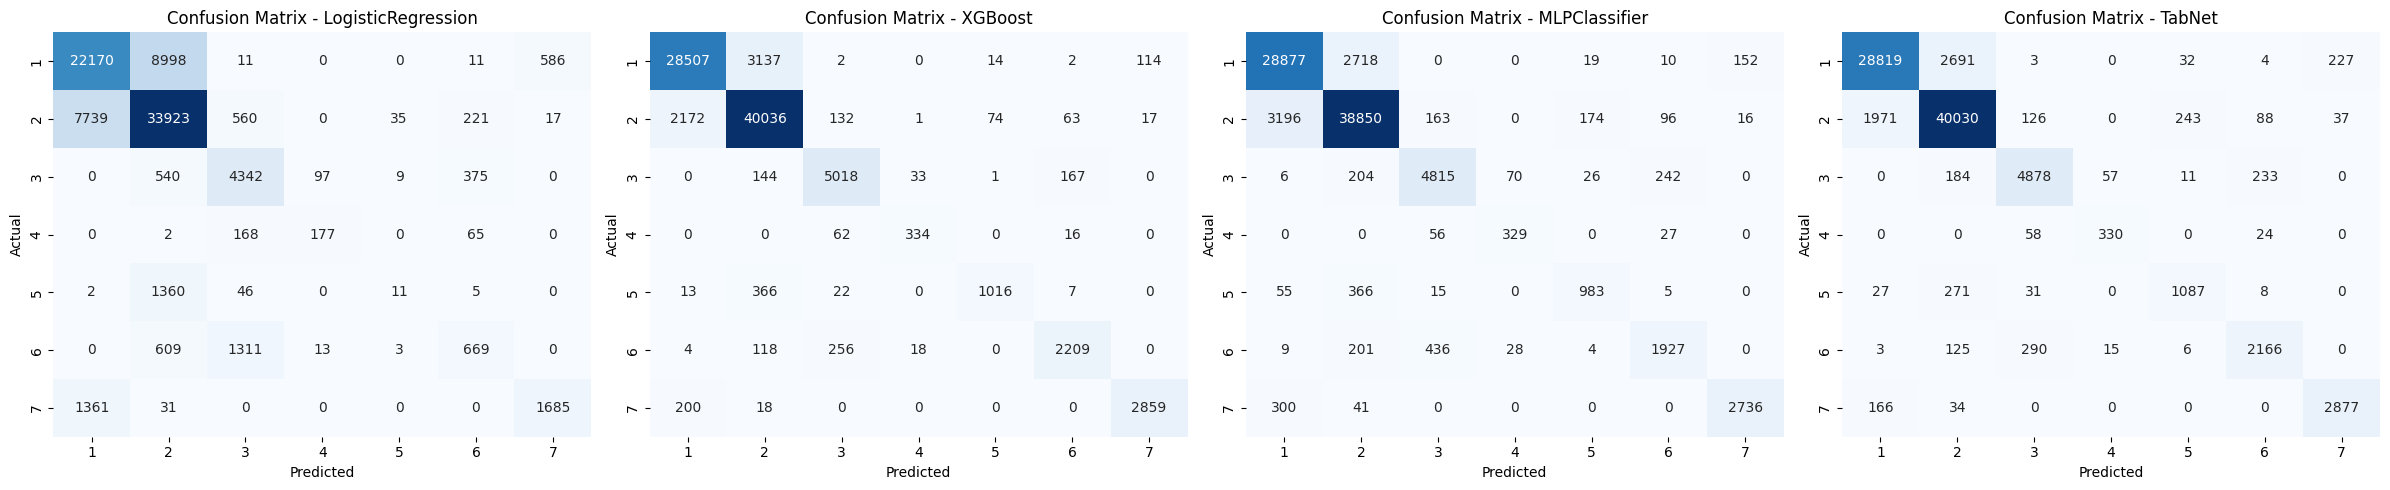

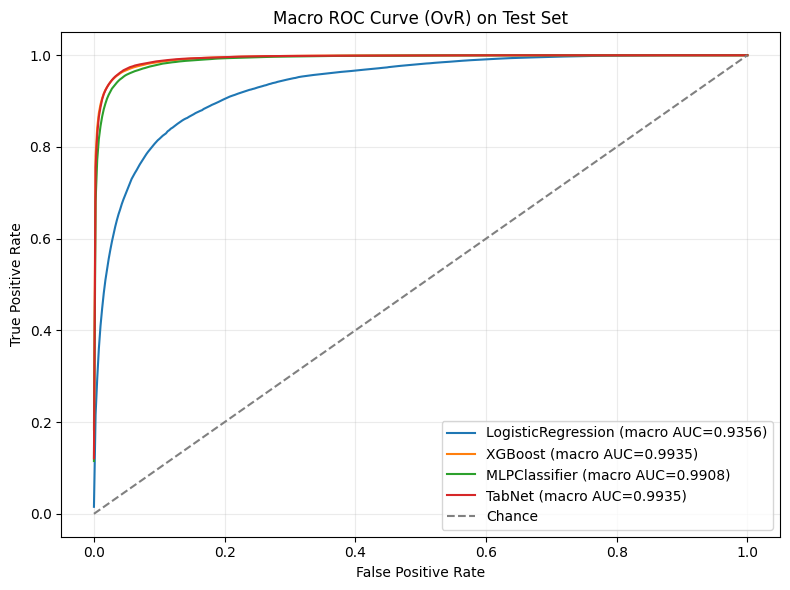

In [14]:
label_names = [str(index_to_class[i]) for i in sorted(index_to_class.keys())]
n_models = len(selected_models)
fig_cm, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (model_family, y_pred) in zip(axes, model_predictions.items()):
    cm = confusion_matrix(y_test_arr, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_title(f"Confusion Matrix - {model_family}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

fig_roc, ax_roc = plt.subplots(figsize=(8, 6))
for model_family, y_score in model_scores.items():
    fpr, tpr = compute_macro_roc_curve(y_test_arr, y_score, N_CLASSES)
    auc_value = test_results[model_family]["roc_auc"]
    ax_roc.plot(fpr, tpr, label=f"{model_family} (macro AUC={auc_value:.4f})")
ax_roc.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax_roc.set_title("Macro ROC Curve (OvR) on Test Set")
ax_roc.set_xlabel("False Positive Rate")
ax_roc.set_ylabel("True Positive Rate")
ax_roc.legend(loc="lower right")
ax_roc.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### Output and result

Confusion matrices reveal where each model mixes specific classes, and the ROC curves confirm very strong separability for top models (especially XGBoost and TabNet).

## 9) Training and inference time benchmark

This code cell benchmarks computational cost by reporting each model's training time and repeated test-time inference latency.

In [15]:
timing_rows = []
for model_family, model in selected_models.items():
    start_infer = time.perf_counter()
    for _ in range(N_INFERENCE_REPEATS):
        _ = model.predict(X_test_scaled)
    infer_total_sec = time.perf_counter() - start_infer
    timing_rows.append({
        "model_family": model_family,
        "train_time_sec": selected_model_info[model_family]["train_time_sec"],
        "inference_total_sec": infer_total_sec,
        "inference_per_sample_ms": (infer_total_sec / (N_INFERENCE_REPEATS * len(X_test_scaled))) * 1000,
    })
timing_df = pd.DataFrame(timing_rows).set_index("model_family")
display(timing_df.style.format("{:.6f}"))

,train_time_sec,inference_total_sec,inference_per_sample_ms
model_family,,,
LogisticRegression,11.636534,0.207730,0.000119
XGBoost,25.236481,35.334718,0.020272
MLPClassifier,126.511048,4.504807,0.002584
TabNet,483.709009,31.450786,0.018044


### Output and result

Runtime trade-off is clear: Logistic Regression is fastest, XGBoost remains efficient for its quality, MLP is slower, and TabNet has the highest training cost.

## 10) Final comparison table and saved artifacts

This code cell builds the final consolidated comparison table (validation + test + timing + best params), saves metrics files, and writes model/scaler artifacts to disk.

In [16]:
final_rows = []
for model_family in selected_models.keys():
    info = selected_model_info[model_family]
    final_rows.append({
        "model_family": model_family,
        "val_accuracy": info["val_accuracy"],
        "val_precision_macro": info["val_precision_macro"],
        "val_recall_macro": info["val_recall_macro"],
        "val_f1_macro": info["val_f1_macro"],
        "val_roc_auc": info["val_roc_auc"],
        "test_accuracy": test_results[model_family]["accuracy"],
        "test_precision_macro": test_results[model_family]["precision_macro"],
        "test_recall_macro": test_results[model_family]["recall_macro"],
        "test_f1_macro": test_results[model_family]["f1_macro"],
        "test_roc_auc": test_results[model_family]["roc_auc"],
        "train_time_sec": timing_df.loc[model_family, "train_time_sec"],
        "inference_per_sample_ms": timing_df.loc[model_family, "inference_per_sample_ms"],
        "best_params": json.dumps(info["best_params"]),
    })

final_comparison_df = pd.DataFrame(final_rows).sort_values("test_f1_macro", ascending=False)
display(final_comparison_df)

comparison_csv_path = METRICS_DIR / "final_comparison_big_dataset.csv"
comparison_json_path = METRICS_DIR / "final_comparison_big_dataset.json"
search_csv_path = METRICS_DIR / "validation_search_results_big_dataset.csv"
coefficients_csv_path = METRICS_DIR / "logreg_coefficients_big_dataset.csv"

search_results_to_save = search_results.copy()
search_results_to_save["params"] = search_results_to_save["params"].apply(json.dumps)
search_results_to_save.to_csv(search_csv_path, index=False)
final_comparison_df.to_csv(comparison_csv_path, index=False)

with open(comparison_json_path, "w", encoding="utf-8") as f:
    json.dump(final_rows, f, indent=2)

if "LogisticRegression" in selected_models:
    logreg_model = selected_models["LogisticRegression"]
    coef_importance = np.abs(logreg_model.coef_).mean(axis=0)
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "mean_abs_coefficient": coef_importance,
    }).sort_values("mean_abs_coefficient", ascending=False)
    coef_df.to_csv(coefficients_csv_path, index=False)

for model_family, model in selected_models.items():
    if model_family == "TabNet":
        model.save_model(str(MODELS_DIR / "TabNet_best"))
    else:
        joblib.dump(model, MODELS_DIR / f"{model_family}_best.joblib")
joblib.dump(scaler, MODELS_DIR / "standard_scaler.joblib")

with open(METRICS_DIR / "feature_columns.json", "w", encoding="utf-8") as f:
    json.dump(feature_cols, f, indent=2)
with open(METRICS_DIR / "class_mapping.json", "w", encoding="utf-8") as f:
    json.dump(index_to_class, f, indent=2)

cm_plot_path = FIGURES_DIR / "confusion_matrices_test.png"
roc_plot_path = FIGURES_DIR / "roc_curves_test.png"
fig_cm.savefig(cm_plot_path, dpi=200, bbox_inches="tight")
fig_roc.savefig(roc_plot_path, dpi=200, bbox_inches="tight")

print("Saved artifacts:")
for p in [comparison_csv_path, comparison_json_path, search_csv_path,
         coefficients_csv_path, cm_plot_path, roc_plot_path,
         MODELS_DIR / "standard_scaler.joblib"]:
    print(f"- {p}")

,model_family,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_roc_auc,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_roc_auc,train_time_sec,inference_per_sample_ms,best_params
1,XGBoost,0.919910,0.914803,0.868450,0.889393,0.993660,0.917696,0.912496,0.868032,0.888082,0.993530,25.236481,0.020272,"{""n_estimators"": 400, ""max_depth"": 8, ""learnin..."
3,TabNet,0.919967,0.877143,0.863501,0.869848,0.993515,0.920082,0.877583,0.869899,0.873616,0.993480,483.709009,0.018044,"{""n_d"": 32, ""n_a"": 32, ""n_steps"": 5, ""gamma"": ..."
2,MLPClassifier,0.900737,0.868656,0.831906,0.849120,0.990752,0.900920,0.863951,0.834082,0.847688,0.990815,126.511048,0.002584,"{""alpha"": 0.0001, ""hidden_layer_sizes"": [256, ..."
0,LogisticRegression,0.724149,0.588879,0.506126,0.526078,0.936612,0.722611,0.595629,0.506766,0.528366,0.935640,11.636534,0.000119,"{""C"": 3.0, ""max_iter"": 300, ""solver"": ""lbfgs""}"


Successfully saved model at /teamspace/studios/this_studio/artifacts/big_dataset/models/TabNet_best.zip
Saved artifacts:
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/final_comparison_big_dataset.csv
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/final_comparison_big_dataset.json
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/validation_search_results_big_dataset.csv
- /teamspace/studios/this_studio/artifacts/big_dataset/metrics/logreg_coefficients_big_dataset.csv
- /teamspace/studios/this_studio/artifacts/big_dataset/figures/confusion_matrices_test.png
- /teamspace/studios/this_studio/artifacts/big_dataset/figures/roc_curves_test.png
- /teamspace/studios/this_studio/artifacts/big_dataset/models/standard_scaler.joblib


### Output and result

The final table confirms overall ranking and trade-offs in one place, and the printed paths confirm that figures, metrics, and model artifacts were saved successfully.

## 11) Analytical discussion (class Q&A prompts)

1. **Why did XGBoost perform so well?**
   It models non-linear feature interactions and handles mixed tabular structure very effectively; here it achieved the best macro-F1 while keeping training time moderate.
2. **Why did TabNet get top accuracy but not top macro-F1?**
   TabNet captured global decision structure well (high accuracy), but XGBoost handled minority/imbalanced-class behavior slightly better in this run (higher macro-F1).
3. **Why is Logistic Regression much weaker?**
   A linear boundary is too restrictive for this problem's class interactions (terrain + hydrology + soil combinations), so both accuracy and macro metrics saturate early.
4. **ML vs DL on this large tabular dataset: who wins?**
   Advanced ML and DL both clearly beat the linear baseline. For a quality-vs-cost balance, **XGBoost is strongest**; for slightly higher raw accuracy, **TabNet is competitive but much more expensive to train**.

## 12) Updated takeaways for the class
Compared with the small-dataset notebook, this large dataset shows the crossover more clearly: simple models stop scaling, while high-capacity tabular models (boosted trees and tabular DL) gain meaningful performance.
